# CIFAR-10 Classification with a Dynamically Weighted Multi-Branch CNN

### ECSXXXX — Deep Learning and Neural Networks with Applications
#### Name: Sarah N.
#### Student Number:

---

This notebook implements a Convolutional Neural Network (CNN) that classifies images from
the **CIFAR-10** dataset.

## Abstract

This project builds and trains a convolutional neural network (CNN) to classify CIFAR-10 images. The network is made of repeated intermediate blocks. Inside each block, several independent convolutional branches process the same input feature map in parallel. The outputs are then combined using weights calculated by the block. To calculate these weights, the block averages each input channel into a single value and passes the resulting values through a small fully connected layer. This produces one weight for each convolutional branch.

Two versions of the network were compared. The basic version uses a simpler configuration while preserving the required block design. The improved version preserves the same defining block structure while increasing network depth and channel width, increasing the number of branches in the deeper blocks, introducing batch normalisation, and adding a hidden output layer with dropout. It was also trained for longer with a higher initial learning rate and label smoothing. Both models used the same data augmentation, weight decay, cosine learning-rate schedule and gradient clipping.

Both models were trained on all 50,000 training images and evaluated on all 10,000 test images. The basic model achieved a best test accuracy of 83.57%. The improved model achieved 91.08% at epoch 57, an increase of 7.51 percentage points. At that epoch, its training accuracy was 97.83%, resulting in a 6.75-point gap between training and test accuracy. This indicates moderate overfitting, although the model still generalised well to the test data. Per-class accuracy ranged from 79.50% for cats, the most difficult class, to 95.90% for cars, the easiest class. Overall, the improved configuration substantially increased classification accuracy while preserving the defining block structure required by the project brief.





## 0. Setup Environment

Imports libraries, device selection, and a fixed random seed for reproducibility.

In [ ]:
import os
import random
import platform
from pathlib import Path

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # Device selection

print(f'Python: {platform.python_version()}')
print(f'PyTorch: {torch.__version__}')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Python: 3.12.13
PyTorch: 2.11.0+cu128
Using device: cuda
GPU: Tesla T4


## 1. Loading the CIFAR-10 dataset

CIFAR-10 contains 60,000 colour images from 10 classes across 10 distinct object and animal classes (Krizhevsky, 2009). Each image has three colour channels and is 32 pixels high by 32 pixels wide. The dataset provides 50,000 images for training and 10,000 images for testing.

**Data preparation**

- **Training data:** A random crop with four pixels of reflection padding and a random horizontal flip introduce small, realistic variations. This helps the model learn features that are less dependent on an object's exact position or orientation. Each image is then converted to a PyTorch tensor and normalised using standard CIFAR-10 channel statistics.

- **Testing data:** Images are converted to tensors and normalised in the same way, but no random augmentation is used. This ensures evaluation is performed on unchanged test images.

The training DataLoader shuffles the images before forming mini-batches. The testing DataLoader keeps a fixed order because shuffling does not affect the calculated evaluation metrics. The retained output confirms that the loaders contain 50,000 training examples, 10,000 testing examples and 391 training batches per epoch.


In [ ]:
# calculates the RGB population mean and standard deviation using all pixels from the 50,000

ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                  transform=transforms.ToTensor())              # pixels scaled to [0,1]
data = torch.stack([img for img, _ in ds])                                      # stack the images
print('mean:', data.mean(dim=(0, 2, 3)))                                        # average over all images, height, width
print('std :', data.std(dim=(0, 2, 3)))                                         # calculate standard deviation

100%|██████████| 170M/170M [20:51<00:00, 136kB/s]


mean: tensor([0.4914, 0.4822, 0.4465])
std : tensor([0.2470, 0.2435, 0.2616])


In [ ]:
# Preparing the training images

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

# transformations and DataLoaders
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),               # augmentation: translation invariance
    transforms.RandomHorizontalFlip(),                                          # augmentation: reflection invariance
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Download + build the datasets
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

BATCH_SIZE = 128
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(device.type == 'cuda'),
                          persistent_workers=True, generator=loader_generator)

test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device.type == 'cuda'),
                          persistent_workers=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Training examples: {len(train_dataset)}')
print(f'Testing examples : {len(test_dataset)}')
print(f'Batches per training epoch: {len(train_loader)}')

Training examples: 50000
Testing examples : 10000
Batches per training epoch: 391


In [ ]:
# verifies that the DataLoader returns batches with the expected image and label shapes
images, labels = next(iter(train_loader))
print('Image batch shape:', images.shape)
print('Label batch shape:', labels.shape)
print('Pixel value range :', f'[{images.min():.2f}, {images.max():.2f}] (normalised)')

Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Pixel value range : [-1.99, 2.13] (normalised)


## 2. The neural network architecture

### 2.1 Intermediate block

The implementation preserves the defining intermediate-block operation required:

1. Compute $m$ = per-channel average of the input $x$ (shape `(b, in_channels)`).
2. Feed $m$ to a fully connected layer with $L$ outputs to get the coefficients $a$ (shape `(b, L)`).
   Note $a$ is computed **per example** — each image in the batch gets its own weighting.
3. Each of the $L$ conv layers processes the **same** input $x$ and produces an output with the **same shape as every other branch in that block** (so they can be summed). The output need not have the same number of channels as the block input.
4. Combine: $x' = \sum_{\ell=1}^{L} a_\ell\, C_\ell(x)$.

In [ ]:
class IntermediateBlock(nn.Module):
    """Required block: parallel independent convolutions with input-dependent weights."""
    def __init__(self, in_channels, out_channels, L, kernel_size=3, stride=1,
                 use_batchnorm=True, use_relu=True, coefficient_init='ones'):
        super().__init__()
        self.L = L
        padding = kernel_size // 2
        branches = []
        for _ in range(L):
            layers = [nn.Conv2d(in_channels, out_channels, kernel_size,
                                stride=stride, padding=padding,
                                bias=not use_batchnorm)]
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_channels))
            if use_relu:
                layers.append(nn.ReLU(inplace=True))
            branches.append(nn.Sequential(*layers))
        self.convs = nn.ModuleList(branches)

        # m has one element per INPUT channel; the FC returns one coefficient per branch.
        self.fc = nn.Linear(in_channels, L)
        if coefficient_init == 'ones':
            nn.init.zeros_(self.fc.weight)
            nn.init.ones_(self.fc.bias)

    def forward(self, x, return_coefficients=False):
        b = x.size(0)
        m = x.mean(dim=(2, 3))                                                  # [B, C_in]
        a = self.fc(m)                                                          # [B, L]
        conv_outs = torch.stack([conv(x) for conv in self.convs], dim=1)
        x_prime = (a.view(b, self.L, 1, 1, 1) * conv_outs).sum(dim=1)
        return (x_prime, a) if return_coefficients else x_prime


### 2.2 Output block

The output block also uses the per-channel averages $m$ of its input (this is a global average
pooling, dimension = number of input channels) and passes $m$ through a small stack of fully
connected layers to produce the 10-dimensional logits vector $o$. We use one hidden FC layer with
a ReLU and dropout, then the final classification layer. Setting `hidden_dims=()` would reduce it
to the minimal "zero hidden layers" version from the brief.

In [ ]:
class OutputBlock(nn.Module):
    """Global-average-pool the final feature map into m, then map m -> logits o
    with zero or more fully connected layers."""
    def __init__(self, in_channels, num_classes=10, hidden_dims=(256,), dropout=0.5):
        super().__init__()
        dims = [in_channels] + list(hidden_dims) + [num_classes]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:                                               # hidden layers get ReLU (+ dropout)
                layers.append(nn.ReLU(inplace=True))
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.fc = nn.Sequential(*layers)

    def forward(self, x):
        m = x.mean(dim=(2, 3))                                                  # per-channel averages -> (b, in_channels)
        o = self.fc(m)                                                          # logits
        return o

### 2.3 The full network

We stack four intermediate blocks with growing channel width ($3\to64\to128\to256\to512$) and
insert a `MaxPool2d(2)` **between** blocks to halve the spatial resolution ($32\to16\to8\to4$).
Adding pooling layers between intermediate blocks is explicitly permitted by the brief as a minor
change. The output block then average-pools the final $512\times4\times4$ map to a 512-vector and
classifies it.

Widening channels while shrinking spatial size is the standard CNN pattern: early layers capture
fine local detail; later layers capture coarse, abstract, class-discriminative features. The use of
deeper feature hierarchies is also common in modern image-classification networks such as ResNet
(He et al., 2016), although this model does not use residual connections.

In [ ]:
class BasicCIFAR10Net(nn.Module):
    """Faithful initial implementation with fewer training enhancements."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            IntermediateBlock(3, 32, L=2, use_batchnorm=False),
            nn.MaxPool2d(2),
            IntermediateBlock(32, 64, L=2, use_batchnorm=False),
            nn.MaxPool2d(2),
            IntermediateBlock(64, 128, L=2, use_batchnorm=False),
        )
        self.output = OutputBlock(128, num_classes, hidden_dims=(), dropout=0.0)

    def forward(self, x):
        return self.output(self.features(x))


class CIFAR10Net(nn.Module):
    """Improved faithful architecture used for the final accuracy result."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = IntermediateBlock(3,   64,  L=2)
        self.pool1  = nn.MaxPool2d(2)
        self.block2 = IntermediateBlock(64,  128, L=2)
        self.pool2  = nn.MaxPool2d(2)
        self.block3 = IntermediateBlock(128, 256, L=3)
        self.pool3  = nn.MaxPool2d(2)
        self.block4 = IntermediateBlock(256, 512, L=3)
        self.output = OutputBlock(512, num_classes, hidden_dims=(256,), dropout=0.5)

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))
        x = self.block4(x)
        return self.output(x)


In [ ]:
model = CIFAR10Net().to(device)
dummy = torch.randn(8, 3, 32, 32, device=device)
out = model(dummy)
assert out.shape == (8, 10), f'Unexpected logits shape: {out.shape}'

check_block = IntermediateBlock(16, 24, L=3).to(device)
check_output, check_a = check_block(torch.randn(4, 16, 8, 8, device=device),
                                    return_coefficients=True)
assert check_output.shape == (4, 24, 8, 8)
assert check_a.shape == (4, 3)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Architecture checks passed.')
print('Output shape:', tuple(out.shape))
print(f'Improved-model trainable parameters: {n_params:,}')


Architecture checks passed.
Output shape: (8, 10)
Improved-model trainable parameters: 4,715,162


## 3. Training and evaluation code

We train with **cross-entropy loss**. `evaluate` computes top-1 accuracy on a loader.
`train_model` runs the optimisation loop and records the three required statistics:
the loss of **every training batch**, and the **train / test accuracy after each epoch**.

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    criterion = criterion or nn.CrossEntropyLoss()
    correct = total = 0
    loss_sum = 0.0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss_sum += criterion(outputs, labels).item() * labels.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return loss_sum / total, 100.0 * correct / total


In [ ]:
def train_model(model, train_loader, test_loader, name, epochs=60,
                lr=0.1, momentum=0.9, weight_decay=5e-4, grad_clip=2.0,
                label_smoothing=0.0):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum,
                                weight_decay=weight_decay, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'batch_loss': [], 'train_acc': [], 'test_acc': [], 'test_loss': []}
    checkpoint_path = Path(f'{name}_best.pt')
    best_acc = -1.0

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            history['batch_loss'].append(loss.item())
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_acc = 100.0 * correct / total
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['test_loss'].append(test_loss)
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({'epoch': epoch + 1, 'model_state': model.state_dict(),
                        'best_test_accuracy': best_acc, 'seed': SEED}, checkpoint_path)
        scheduler.step()
        print(f'{name:8s} | epoch {epoch + 1:3d}/{epochs} | '
              f'train {train_acc:6.2f}% | test {test_acc:6.2f}% | '
              f'test loss {test_loss:.4f}')

    saved = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(saved['model_state'])
    print(f"Restored {name} best checkpoint: epoch {saved['epoch']}, "
          f"test accuracy {saved['best_test_accuracy']:.2f}%")
    return model, history, checkpoint_path


## 4. Training the network

We first train a deliberately basic version, then the improved model. Runtime and accuracy depend on the allocated Colab hardware. The stored output from the final clean run is the evidence used in the results section.

In [ ]:
BASIC_EPOCHS = 20
IMPROVED_EPOCHS = 60

seed_everything()
basic_model = BasicCIFAR10Net().to(device)
basic_model, basic_history, basic_checkpoint = train_model(
    basic_model, train_loader, test_loader, 'basic', epochs=BASIC_EPOCHS,
    lr=0.03, grad_clip=2.0)

seed_everything()
model = CIFAR10Net().to(device)
model, improved_history, improved_checkpoint = train_model(
    model, train_loader, test_loader, 'improved', epochs=IMPROVED_EPOCHS,
    lr=0.1, grad_clip=2.0, label_smoothing=0.1)

basic_loss, basic_acc = evaluate(basic_model, test_loader)
final_test_loss, final_test_acc = evaluate(model, test_loader)
best_test_acc = max(improved_history['test_acc'])
print(f'\nBasic best-checkpoint test accuracy: {basic_acc:.2f}%')
print(f'Improved best-checkpoint test accuracy: {final_test_acc:.2f}%')
print(f'Improvement: {final_test_acc - basic_acc:+.2f} percentage points')
print('Best checkpoints:', basic_checkpoint, improved_checkpoint)


basic    | epoch   1/20 | train  35.93% | test  47.48% | test loss 1.4572
basic    | epoch   2/20 | train  53.28% | test  59.66% | test loss 1.1381
basic    | epoch   3/20 | train  60.79% | test  65.20% | test loss 0.9828
basic    | epoch   4/20 | train  65.43% | test  66.43% | test loss 0.9451
basic    | epoch   5/20 | train  68.41% | test  68.42% | test loss 0.8988
basic    | epoch   6/20 | train  71.29% | test  72.21% | test loss 0.8047
basic    | epoch   7/20 | train  73.10% | test  73.13% | test loss 0.7910
basic    | epoch   8/20 | train  74.80% | test  75.41% | test loss 0.7031
basic    | epoch   9/20 | train  76.28% | test  76.73% | test loss 0.6788
basic    | epoch  10/20 | train  77.65% | test  77.35% | test loss 0.6667
basic    | epoch  11/20 | train  79.03% | test  78.69% | test loss 0.6341
basic    | epoch  12/20 | train  80.28% | test  78.89% | test loss 0.6078
basic    | epoch  13/20 | train  81.28% | test  80.52% | test loss 0.5718
basic    | epoch  14/20 | train  82.40

## 5. Data Visualisation

The following figures show:

1. the cross-entropy loss recorded after every training mini-batch; and
2. the training and testing accuracy recorded after every epoch.

The full loss history is shown on a logarithmic scale because the improved model produced one large early loss value. A second, zoomed graph shows the central 99% of the loss values so that the usual training behaviour can also be seen clearly.

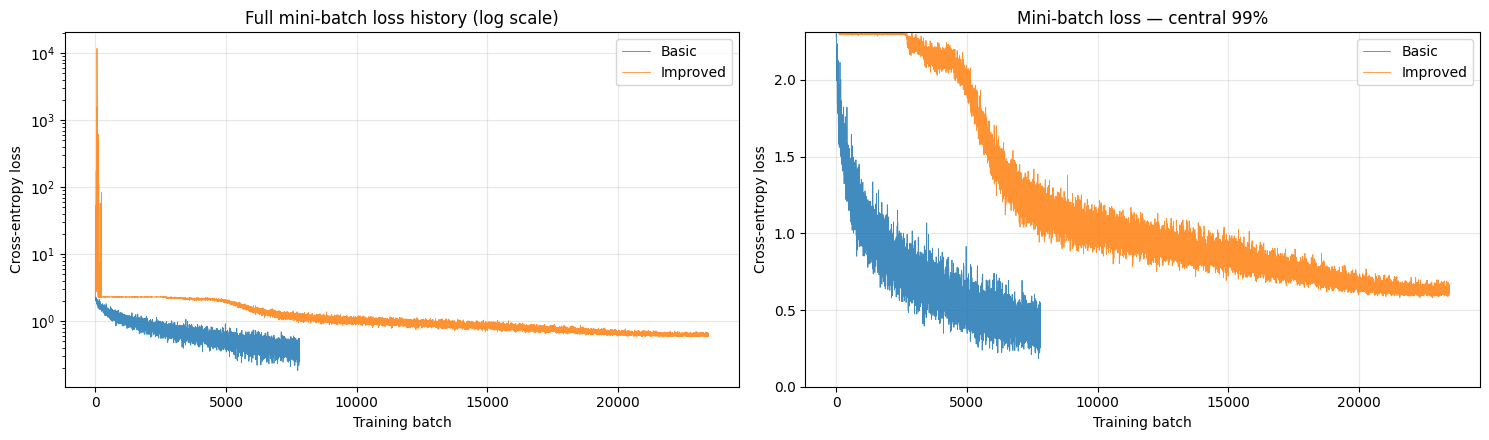

In [ ]:
# Collect the losses from both models
all_losses = np.concatenate([
    np.asarray(basic_history['batch_loss']),
    np.asarray(improved_history['batch_loss'])
])

# The 99th percentile
zoom_limit = np.percentile(all_losses, 99)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

for label, history in [
    ('Basic', basic_history),
    ('Improved', improved_history)
]:
    losses = history['batch_loss']

    axes[0].plot(losses, linewidth=0.6, alpha=0.85, label=label)
    axes[1].plot(losses, linewidth=0.6, alpha=0.85, label=label)

# Full loss history
axes[0].set_yscale('log')
axes[0].set_title('Full mini-batch loss history (log scale)')
axes[0].set_xlabel('Training batch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Zoomed loss history
axes[1].set_ylim(0, zoom_limit)
axes[1].set_title('Mini-batch loss — central 99%')
axes[1].set_xlabel('Training batch')
axes[1].set_ylabel('Cross-entropy loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Produce a summary directly from the recorded results
def summarise(history):
    best_index = int(np.argmax(history['test_acc']))

    return {
        'epochs': len(history['test_acc']),
        'best_epoch': best_index + 1,
        'best_test_acc': history['test_acc'][best_index],
        'train_acc_at_best': history['train_acc'][best_index],
        'test_loss_at_best': history['test_loss'][best_index],
        'final_test_acc': history['test_acc'][-1],
        'final_train_acc': history['train_acc'][-1]
    }


basic_stats = summarise(basic_history)
improved_stats = summarise(improved_history)

for name, stats in [
    ('Basic', basic_stats),
    ('Improved', improved_stats)
]:
    print(f'\n{name} model')
    print(f"  Training epochs: {stats['epochs']}")
    print(f"  Best epoch: {stats['best_epoch']}")
    print(f"  Training accuracy at best epoch: "
          f"{stats['train_acc_at_best']:.2f}%")
    print(f"  Best test accuracy: "
          f"{stats['best_test_acc']:.2f}%")
    print(f"  Test loss at best epoch: "
          f"{stats['test_loss_at_best']:.4f}")
    print(f"  Final test accuracy: "
          f"{stats['final_test_acc']:.2f}%")

accuracy_improvement = (
    improved_stats['best_test_acc']
    - basic_stats['best_test_acc']
)

improved_gap = (
    improved_stats['train_acc_at_best']
    - improved_stats['best_test_acc']
)

print(
    f'\nImprovement over the basic model: '
    f'{accuracy_improvement:.2f} percentage points'
)

print(
    f'Improved-model training–test gap at its best epoch: '
    f'{improved_gap:.2f} percentage points'
)


Basic model
  Training epochs: 20
  Best epoch: 20
  Training accuracy at best epoch: 86.16%
  Best test accuracy: 83.57%
  Test loss at best epoch: 0.4982
  Final test accuracy: 83.57%

Improved model
  Training epochs: 60
  Best epoch: 57
  Training accuracy at best epoch: 97.83%
  Best test accuracy: 91.08%
  Test loss at best epoch: 0.7294
  Final test accuracy: 90.91%

Improvement over the basic model: 7.51 percentage points
Improved-model training–test gap at its best epoch: 6.75 percentage points


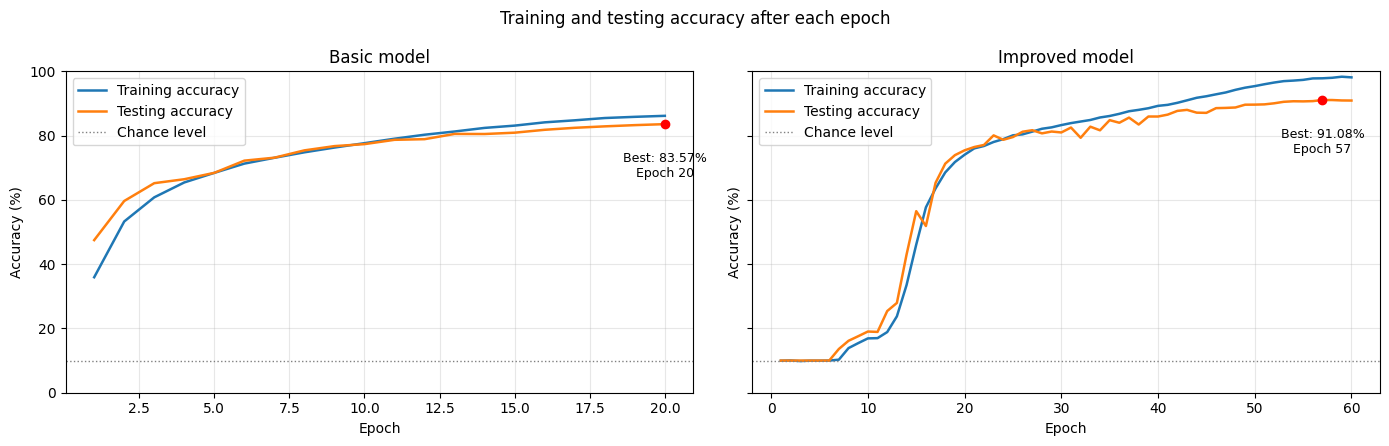

In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 4.5),
    sharey=True
)

for ax, label, history in [
    (axes[0], 'Basic', basic_history),
    (axes[1], 'Improved', improved_history)
]:
    epochs = np.arange(1, len(history['train_acc']) + 1)

    train_accuracy = np.asarray(history['train_acc'])
    test_accuracy = np.asarray(history['test_acc'])

    # Find the epoch with the highest test accuracy
    best_index = int(np.argmax(test_accuracy))
    best_epoch = best_index + 1
    best_accuracy = test_accuracy[best_index]

    ax.plot(
        epochs,
        train_accuracy,
        label='Training accuracy',
        linewidth=1.8
    )

    ax.plot(
        epochs,
        test_accuracy,
        label='Testing accuracy',
        linewidth=1.8
    )

    # CIFAR-10 has 10 classes, so random chance is approximately 10%
    ax.axhline(
        10,
        color='grey',
        linestyle=':',
        linewidth=1,
        label='Chance level'
    )

    # Mark the best test result
    ax.scatter(
        best_epoch,
        best_accuracy,
        color='red',
        zorder=3
    )

    ax.annotate(
        f'Best: {best_accuracy:.2f}%\nEpoch {best_epoch}',
        xy=(best_epoch, best_accuracy),
        xytext=(0, -38),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

    ax.set_title(f'{label} model')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Training and testing accuracy after each epoch')
plt.tight_layout()
plt.show()

In [ ]:
# Per-class test accuracy of the improved model
@torch.no_grad()
def per_class_accuracy(model, loader, n_classes=10):
    model.eval()
    correct = np.zeros(n_classes); total = np.zeros(n_classes)
    for images, labels in loader:
        preds = model(images.to(device, non_blocking=True)).argmax(1).cpu()
        for c in range(n_classes):
            mask = labels == c
            total[c] += mask.sum().item()
            correct[c] += (preds[mask] == c).sum().item()
    return 100.0 * correct / np.maximum(total, 1)

pc = per_class_accuracy(model, test_loader)
order = np.argsort(pc)
print('Per-class test accuracy (improved model), worst to best:')
for c in order:
    print(f'  {classes[c]:<7} {pc[c]:6.2f}%')
print(f'\nMean per-class accuracy: {pc.mean():.2f}%')
print(f'Hardest classes: {classes[order[0]]} and {classes[order[1]]} '
      f'- visually similar animal categories on CIFAR-10.')


Per-class test accuracy (improved model), worst to best:
  cat      79.50%
  dog      84.90%
  bird     87.50%
  deer     92.60%
  plane    92.80%
  horse    93.70%
  ship     94.20%
  frog     94.50%
  truck    95.20%
  car      95.90%

Mean per-class accuracy: 91.08%
Hardest classes: cat and dog - visually similar animal categories on CIFAR-10.


## 6. Results, hyperparameters and training techniques

### Final performance

The basic model achieved a best-checkpoint test accuracy of **83.57% at epoch 20**. The improved model achieved **91.08% at epoch 57**, representing an increase of **7.51 percentage points**. The improved model's training accuracy at its best epoch was 97.83%, producing a training-test gap of 6.75 percentage points. Its final-epoch test accuracy was 90.91%, so restoring the epoch-57 checkpoint retained the strongest observed model.

### Hyperparameters

| Setting | Basic model | Improved model | Reason |
|---|---:|---:|---|
| Loss | Cross-entropy | Cross-entropy with 0.1 label smoothing | Appropriate for multi-class logits; smoothing reduces over-confident predictions. |
| Optimiser | SGD with Nesterov momentum | SGD with Nesterov momentum | Momentum helps optimisation progress in consistent directions. |
| Initial learning rate | 0.03 | 0.10 | The batch-normalised improved model can support a larger initial step size. |
| Momentum | 0.9 | 0.9 | A standard value that reduces oscillation during SGD. |
| Weight decay | 5e-4 | 5e-4 | Regularises the model parameters. |
| Batch size | 128 | 128 | Balances GPU memory, speed and gradient stability. |
| Epochs | 20 | 60 | The improved model was given a longer schedule to converge. |
| Learning-rate schedule | Cosine annealing | Cosine annealing | Gradually reduces the learning rate towards the end of training; the cosine form is based on SGDR, but no warm restarts were used (Loshchilov and Hutter, 2017). |
| Gradient clipping | Maximum norm 2.0 | Maximum norm 2.0 | Limits instability from learned multiplicative branch coefficients. |
| Data augmentation | Random crop and horizontal flip | Random crop and horizontal flip | Shared training control that encourages position and reflection robustness. |
| Dropout | None in output block | 0.5 in hidden output layer | Reduces co-adaptation in the larger classifier. |
| Coefficient initialisation | One per branch | One per branch | Begins training from an equal-weighted branch combination. |

Both models used the same random cropping, horizontal flipping, normalisation, weight decay, cosine learning-rate schedule, gradient clipping, Nesterov momentum, ReLU activations and coefficient initialisation. These shared controls cannot explain the measured difference between the models. The improved configuration differed through greater depth and channel width, additional branches in the deeper blocks, batch normalisation, a hidden output layer with dropout, label smoothing, a higher initial learning rate and a longer training schedule.

Following the project instructions, the test set was used to compare the models and select the best saved checkpoint. In a larger research project, a separate validation set would normally be used for these decisions. The test set would then be used only once for the final evaluation.


## 6.1 Measured comparison and learning-curve analysis

| Model | Epochs | Best epoch | Training accuracy at best epoch | Best test accuracy | Test loss at best epoch | Difference from basic |
|---|---:|---:|---:|---:|---:|---:|
| Basic faithful model | 20 | 20 | 86.16% | **83.57%** | 0.4982 | - |
| Improved model | 60 | 57 | 97.83% | **91.08%** | 0.7294 | **+7.51 points** |

The loss values for the two models cannot be compared directly because the improved model used label smoothing, while the basic model did not. Accuracy is therefore a clearer way to compare their performance.

The basic model improved steadily during its 20 training epochs. Its test accuracy increased from 47.48% in the first epoch to 83.57% in the final epoch. At epoch 20, its training accuracy was 86.16%, giving a 2.59 percentage-point gap. Because its accuracy was still increasing, training it for longer may have produced a better result.

The very large early mini-batch loss and chance-level accuracy during the first six epochs indicate initial optimisation instability in the improved run. Training subsequently recovered and converged steadily: test accuracy reached 80.07% at epoch 23, 88.01% at epoch 43 and its highest value of 91.08% at epoch 57. It then fell slightly to 90.91% at epoch 60. This shows why retaining the full loss history and restoring the best checkpoint were useful. The experiment does not isolate the cause of the recovery.

At the best epoch, the improved model achieved 97.83% training accuracy and 91.08% test accuracy. The difference was 6.75 percentage points, which suggests moderate overfitting. Dropout and label smoothing were additions specific to the improved configuration, while data augmentation and weight decay were shared by both models. These regularisation measures did not completely remove the gap.

Overall, the improved model performed 7.51 percentage points better than the basic model. However, several architectural and training changes were made at the same time, and the models had unequal training budgets. The experiment therefore shows that the final configuration worked well as a whole, but it cannot attribute the gain to any individual change.


## 7. Discussion of improvements and references

### Interpretation of the improvement

The improved model increased best-checkpoint test accuracy from 83.57% to 91.08%. This 7.51-point gain shows that the combined architectural and training changes were effective under the experimental protocol. The improved network increased depth from three to four intermediate blocks, expanded channel width from a maximum of 128 to 512, and used three branches rather than two in its two deepest blocks. This provided greater capacity for learning varied visual features. A third pooling stage reduced spatial resolution from 32 by 32 to 4 by 4, increasing the effective receptive field while controlling later computational cost.

Also, the improved configuration added batch normalisation to its convolutional branches (Ioffe and Szegedy, 2015) and a 256-unit hidden output layer with dropout. It also introduced label smoothing, used a higher initial learning rate and trained for 60 rather than 20 epochs. By contrast, ReLU activations, data augmentation, weight decay, cosine annealing, gradient clipping, Nesterov momentum and equal branch-coefficient initialisation were shared between both models. They are relevant training controls, but they cannot explain the measured 7.51-point difference because they were not varied between the two runs. The cosine schedule follows the decay form introduced with SGDR, although the present experiment did not use warm restarts (Loshchilov and Hutter, 2017).

The learning curves show that the improved run experienced substantial initial optimisation instability before converging to a much higher accuracy. Its 6.75-point training-test gap at the best epoch provides evidence of moderate overfitting. The final three epochs did not improve on epoch 57, demonstrating the value of saving and restoring the best checkpoint. No individual technique can be credited with the recovery or the final gain because the experiment did not vary the changes separately.

### Per-class behaviour

Performance varied across CIFAR-10 classes. The improved model achieved its lowest accuracies for cats (79.50%) and dogs (84.90%). These classes can share similar shapes, textures and backgrounds, making them difficult to separate at a resolution of 32 by 32 pixels. Cars (95.90%), trucks (95.20%), frogs (94.50%) and ships (94.20%) were classified more accurately. The mean per-class accuracy was 91.08%, matching the overall result because CIFAR-10 contains the same number of test examples in each class.

### Relationship to existing methods

The required block is related to the parallel convolutional processing used in Inception networks (Szegedy et al., 2015; Szegedy et al., 2016). The improved model also follows the broader deep-CNN pattern of learning increasingly abstract features through a deeper hierarchy (He et al., 2016), although it does not use residual connections. Unlike standard Inception or ResNet blocks, the present model gives each whole convolutional branch an input-dependent weight and preserves the defining operation required by the project brief.

### Limitations and further work

The comparison used one random seed, so it does not measure variation between training runs. The basic model was also trained for fewer epochs than the improved model, and its accuracy was still increasing at epoch 20. The result therefore demonstrates that the final configuration was better under the chosen training budgets, but it does not provide a controlled architectural ablation. Also, several improvements were introduced simultaneously, preventing their individual effects from being isolated.

Future work could use the same epoch budget for both models, repeat each experiment using several seeds and add one technique at a time. Stronger augmentation, such as Cutout (DeVries and Taylor, 2017), could also be investigated while retaining the required dynamically weighted blocks.

## 8. Conclusion

The improved model achieved a best test accuracy of 91.08% at epoch 57, outperforming the basic model's 83.57% by 7.51 percentage points. This substantial gain shows that the final combination of greater depth and width, additional branches, batch normalisation, a hidden output layer with dropout, label smoothing and a longer training schedule was effective for CIFAR-10 classification.

The learning curves reveal substantial instability during the first six epochs, followed by a clear recovery and steady convergence. At the best epoch, the improved model reached 97.83% training accuracy, leaving a 6.75-point training-test gap and indicating moderate overfitting. Performance also varied by class: cars achieved the highest accuracy at 95.90%, while cats and dogs were the most difficult at 79.50% and 84.90%, respectively.

Overall, the results demonstrate a strong improvement while preserving the required dynamically weighted multi-branch structure. However, because the comparison used one random seed, unequal training budgets and several simultaneous changes, the contribution of each individual modification cannot be isolated. Controlled ablation experiments with equal training schedules would provide a more precise assessment of which changes produced the largest gains.


### References

- Krizhevsky, A. (2009) *Learning multiple layers of features from tiny images*. Toronto: University of Toronto. Available at: https://www.researchgate.net/publication/265748773_Learning_Multiple_Layers_of_Features_from_Tiny_Images (Accessed: 14 August 2026).
- Ioffe, S. and Szegedy, C. (2015) 'Batch normalization: Accelerating deep network training by reducing internal covariate shift', in *Proceedings of the 32nd International Conference on Machine Learning*, pp. 448-456. Available at: https://arxiv.org/abs/1502.03167 (Accessed: 14 August 2026).
- Szegedy, C. et al. (2015) 'Going deeper with convolutions', in *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, pp. 1-9. Available at: https://ieeexplore.ieee.org/document/7298594 (Accessed: 14 August 2026).
- Szegedy, C. et al. (2016) 'Rethinking the Inception architecture for computer vision', in *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, pp. 2818-2826. Available at: https://arxiv.org/abs/1512.00567 (Accessed: 14 August 2026).
- He, K., Zhang, X., Ren, S. and Sun, J. (2016) 'Deep residual learning for image recognition', in *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, pp. 770-778. Available at: https://arxiv.org/abs/1512.03385 (Accessed: 14 August 2026).
- Loshchilov, I. and Hutter, F. (2017) 'SGDR: Stochastic gradient descent with warm restarts', in *5th International Conference on Learning Representations*. Available at: https://arxiv.org/abs/1608.03983 (Accessed: 14 August 2026).
- DeVries, T. and Taylor, G.W. (2017) *Improved regularization of convolutional neural networks with Cutout*. arXiv:1708.04552. Available at: https://arxiv.org/abs/1708.04552 (Accessed: 14 August 2026).
